In [2]:
import shap
import joblib
import pandas as pd

In [3]:
model = joblib.load("../models/churn_prediction_model.pkl")

In [4]:
df = pd.read_csv("../data/processed/feature_engineered_data.csv")

In [5]:
X = df.drop("Churn Value", axis=1)
y = df["Churn Value"]

In [6]:
preprocessor = model.named_steps["preprocessor"]
classifier = model.named_steps["classifier"]

In [7]:
X_processed = preprocessor.transform(X)

In [8]:
feature_names = preprocessor.get_feature_names_out()

In [9]:
explainer = shap.TreeExplainer(classifier)

In [10]:
shap_values = explainer.shap_values(X_processed)

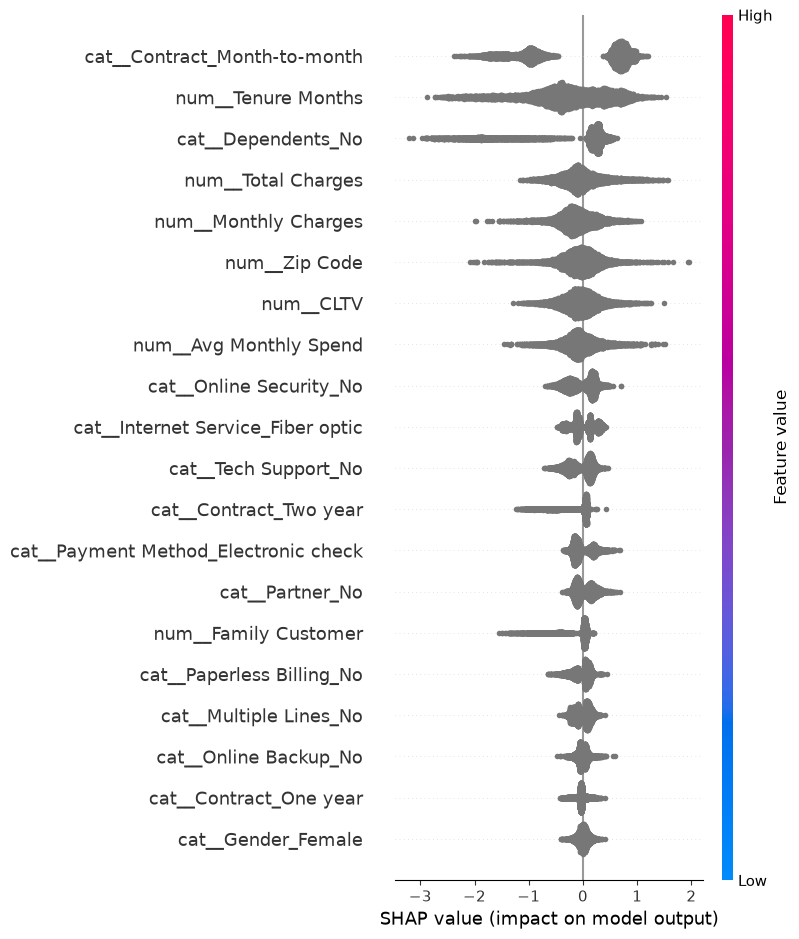

In [11]:
shap.summary_plot(
    shap_values,
    X_processed,
    feature_names=feature_names
)

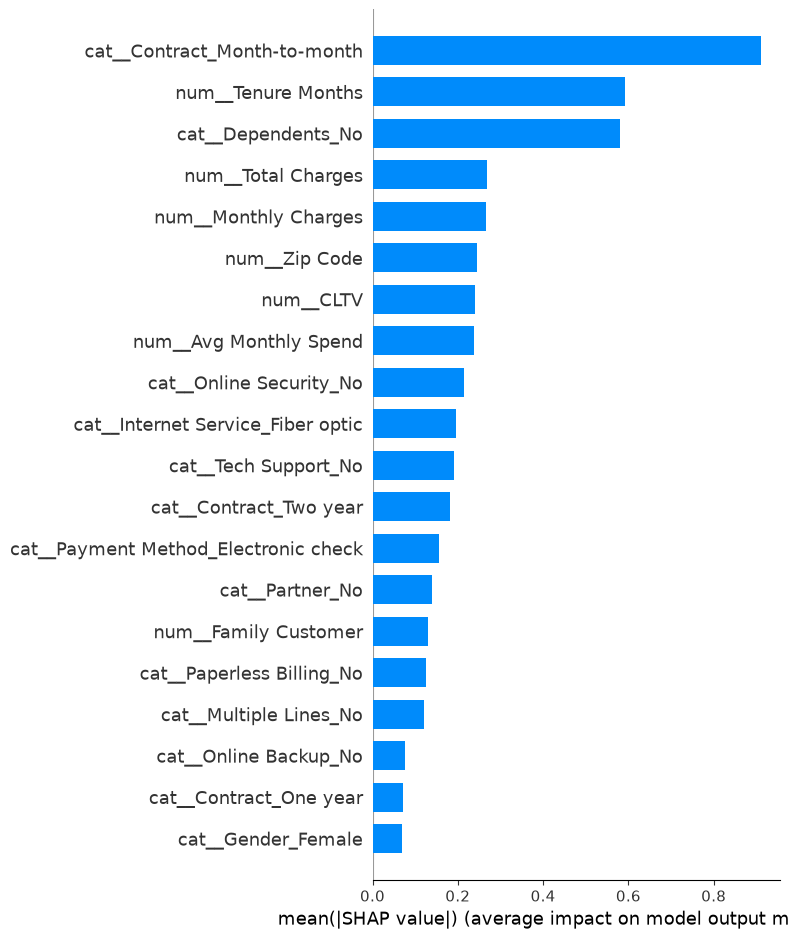

In [12]:
shap.summary_plot(
    shap_values,
    X_processed,
    feature_names=feature_names,
    plot_type="bar"
)

In [16]:
import shap
print(shap.__version__)

0.52.0


In [17]:
X_processed_dense = X_processed.toarray()

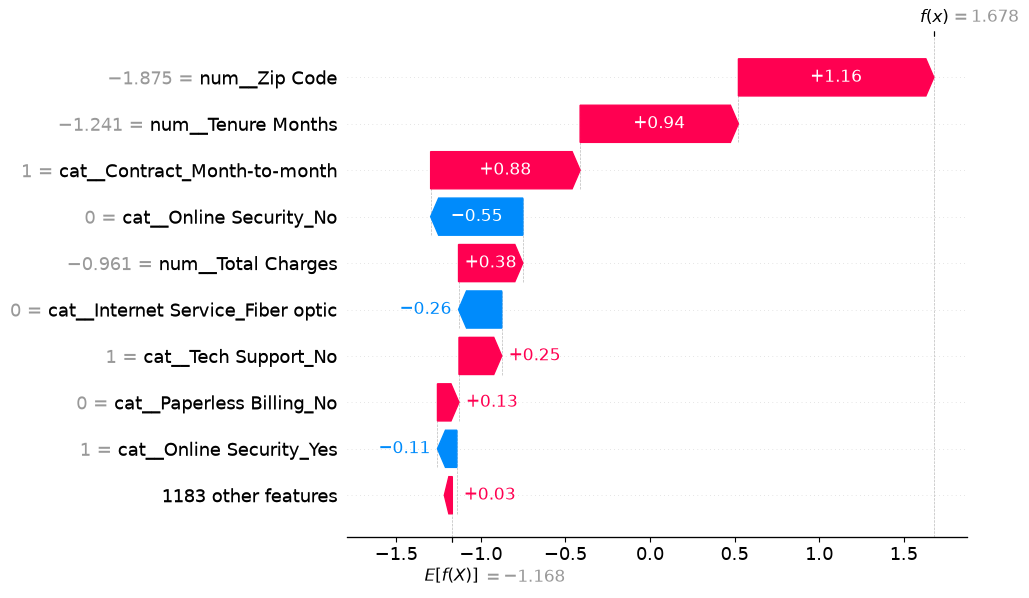

In [18]:
customer_index = 0

explanation = shap.Explanation(
    values=shap_values[customer_index],
    base_values=explainer.expected_value,
    data=X_processed_dense[customer_index],
    feature_names=feature_names
)

shap.plots.waterfall(explanation)

# Phase 9: Explainable AI (SHAP)

## Objective
Use SHAP (SHapley Additive exPlanations) to understand how the machine learning model predicts customer churn.

## Goals
- Explain model predictions.
- Identify the most important features affecting churn.
- Interpret individual customer predictions.
- Provide actionable business insights.

## Business Value
Explainable AI increases trust in the model by showing why customers are likely to churn, helping businesses make better retention decisions.